In [2]:
import math
import gymnasium as gym
from gymnasium import spaces
from typing import Dict
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3 import A2C, SAC
from gym.wrappers import FlattenObservation
from typing import Tuple, Dict, Optional, Any
import matplotlib.pyplot as plt
from stable_baselines3.common.utils import get_linear_fn
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import SubprocVecEnv
import numpy as np
import random
from scipy.optimize import brentq
import torch
import torch.nn as nn
import torch.optim as optim
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from environments import KyleOnePeriodAEC

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [39]:
import numpy as np
import pettingzoo
from collections import defaultdict

# --- 1. Model & Game Configuration ---
# (User needs to define these based on their discretized model)
# Example:
# INSIDER_ACTIONS = np.array([-1.0, -0.5, 0.0, 0.5, 1.0])
# MM_ACTIONS = np.array([0.5, 1.0, 1.5, 2.0, 2.5])
# NUM_PERIODS = 10 # Number of turns in one episode

def calculate_utility(agent_name, my_action, opponent_action, true_value):
    """
    Placeholder for the Kyle model's utility function.
    You must implement this based on your model's math.
    
    Args:
        agent_name (str): 'insider' or 'market_maker'
        my_action (float): The action taken by this agent.
        opponent_action (float): The action taken by the opponent.
        
    Returns:
        float: The utility (profit/loss) for the agent in this turn.
    """
    # Example logic (replace with your actual calculations)
    if agent_name == 'insider':
        # Profit might be: my_action * (true_value - price)
        
        return my_action * (true_value - opponent_action)
    else: # market_maker

        return - (my_action - true_value) ** 2


# --- 2. Regret Matching Helper Functions ---

def get_strategy(regret_sum):
    """Calculates the current strategy from a regret sum vector."""
    positive_regrets = np.maximum(0, regret_sum)
    normalizing_sum = np.sum(positive_regrets)
    
    if normalizing_sum > 0:
        return positive_regrets / normalizing_sum
    else:
        # Fallback to uniform random strategy
        return np.ones(len(regret_sum)) / len(regret_sum)

def sample_action(strategy, action_set):
    """Samples an action value from a strategy distribution."""
    action_index = np.random.choice(len(action_set), p=strategy)
    return action_set[action_index]

# --- 3. The Main Training Loop ---

def train_regret_matching(env: pettingzoo.AECEnv, num_episodes: int):
    """
    Trains two agents in the Kyle model environment using per-state Regret Matching.
    """
    agents = env.possible_agents
    # Discretize actions (choose resolution)
    INSIDER_ACTIONS = np.linspace(-5, 5, 125)
    MM_ACTIONS      = np.linspace(-5, 5, 125)
    action_spaces = {
        'insider': INSIDER_ACTIONS,
        'market_maker': MM_ACTIONS
    }
    num_actions = {name: len(spaces) for name, spaces in action_spaces.items()}

    # --- Initialize data structures ---
    # regrets[agent][period_k][action_idx]
    regret_sum = {
        agent: np.zeros((NUM_PERIODS, num_actions[agent])) for agent in agents
    }
    # strategy_sum is used to compute the final average strategy
    strategy_sum = {
        agent: np.zeros((NUM_PERIODS, num_actions[agent])) for agent in agents
    }
    # empirical_dist tracks joint action counts for CCE verification
    empirical_dist = np.zeros((NUM_PERIODS, num_actions['insider'], num_actions['market_maker']))
    
    print(f"Starting training for {num_episodes} episodes...")

    for episode in range(num_episodes):
        if (episode + 1) % 1000 == 0:
            print(f"  Episode {episode + 1}/{num_episodes}")
            
        env.reset()
        
        # --- Run a single episode ---
        # The state 'k' is the current time period in the episode
        for k in range(NUM_PERIODS):
            
            # --- Get strategies for the current state k ---
            strategies = {
                agent: get_strategy(regret_sum[agent][k]) for agent in agents
            }
            
            # --- Agents play their turn for period k ---
            # In Kyle's model, Insider moves, then Market Maker reacts
            insider_action = sample_action(strategies['insider'], action_spaces['insider'])
            # NOTE: PettingZoo loop is not used here for simplicity, assuming a fixed turn order.
            # You would step the env with the insider's action to get the MM's observation.
            mm_action = sample_action(strategies['market_maker'], action_spaces['market_maker'])
            
            # --- Update empirical distribution ---
            insider_action_idx = np.where(action_spaces['insider'] == insider_action)[0][0]
            mm_action_idx = np.where(action_spaces['market_maker'] == mm_action)[0][0]
            empirical_dist[k, insider_action_idx, mm_action_idx] += 1

            # Insider moves
            env.step(np.array([insider_action], dtype=np.float32))

            # MM moves
            env.step(np.array([mm_action], dtype=np.float32))
            
            # --- Update regrets for both agents for state k ---
            for agent in agents:
                my_action = insider_action if agent == 'insider' else mm_action
                opponent_action = mm_action if agent == 'insider' else insider_action
                
                # Calculate utility for the action actually taken
                actual_utility = calculate_utility(agent, my_action, opponent_action, env.v)
                
                # Calculate counterfactual utilities for all possible actions
                for i, possible_action in enumerate(action_spaces[agent]):
                    counterfactual_utility = calculate_utility(agent, possible_action, opponent_action, env.v)
                    regret = counterfactual_utility - actual_utility
                    regret_sum[agent][k, i] += regret

            # --- Update strategy sums for the average strategy calculation ---
            for agent in agents:
                strategy_sum[agent][k] += strategies[agent]
                
    print("Training finished.")

    # --- 4. Calculate Final Results ---
    # Normalize the empirical distribution to get the CCE candidate
    total_plays_per_period = np.sum(empirical_dist, axis=(1, 2), keepdims=True)
    cce_distribution = empirical_dist / total_plays_per_period

    # Calculate the average strategies from the strategy sums
    avg_strategies = {
        agent: strategy_sum[agent] / np.sum(strategy_sum[agent], axis=1, keepdims=True)
        for agent in agents
    }

    return cce_distribution, avg_strategies





# --- Example Usage ---
if __name__ == '__main__':
    # 1. Instantiate your PettingZoo AEC environment
    env = KyleOnePeriodAEC()
    NUM_PERIODS = env.T
    # 2. Run the training
    cce_dist, avg_strats = train_regret_matching(env, num_episodes=50000)



Starting training for 50000 episodes...
  Episode 1000/50000
  Episode 2000/50000
  Episode 3000/50000
  Episode 4000/50000
  Episode 5000/50000
  Episode 6000/50000
  Episode 7000/50000
  Episode 8000/50000
  Episode 9000/50000
  Episode 10000/50000
  Episode 11000/50000
  Episode 12000/50000
  Episode 13000/50000
  Episode 14000/50000
  Episode 15000/50000
  Episode 16000/50000
  Episode 17000/50000
  Episode 18000/50000
  Episode 19000/50000
  Episode 20000/50000
  Episode 21000/50000
  Episode 22000/50000
  Episode 23000/50000
  Episode 24000/50000
  Episode 25000/50000
  Episode 26000/50000
  Episode 27000/50000
  Episode 28000/50000
  Episode 29000/50000
  Episode 30000/50000
  Episode 31000/50000
  Episode 32000/50000
  Episode 33000/50000
  Episode 34000/50000
  Episode 35000/50000
  Episode 36000/50000
  Episode 37000/50000
  Episode 38000/50000
  Episode 39000/50000
  Episode 40000/50000
  Episode 41000/50000
  Episode 42000/50000
  Episode 43000/50000
  Episode 44000/50000
 

In [40]:
import matplotlib.pyplot as plt

def plot_cce_heatmap(cce_dist, insider_actions, mm_actions, period=0):
    """
    Plots a heatmap of the joint action distribution at a given period k.
    """
    plt.figure(figsize=(8, 6))
    plt.imshow(cce_dist[period], aspect='auto', origin='lower')
    plt.colorbar(label="Probability")

    plt.title(f"CCE Joint Action Distribution (Period {period})")
    plt.xlabel("Market Maker Action Index")
    plt.ylabel("Insider Action Index")

    # Optional: put actual action labels
    plt.xticks(
        ticks=range(len(mm_actions))[::10],
        labels=np.round(mm_actions[::10], 2),
        rotation=90
    )
    plt.yticks(
        ticks=range(len(insider_actions))[::10],
        labels=np.round(insider_actions[::10], 2)
    )

    plt.show()


In [41]:
INSIDER_ACTIONS = np.linspace(-5, 5, 125)
MM_ACTIONS      = np.linspace(-5, 5, 125)


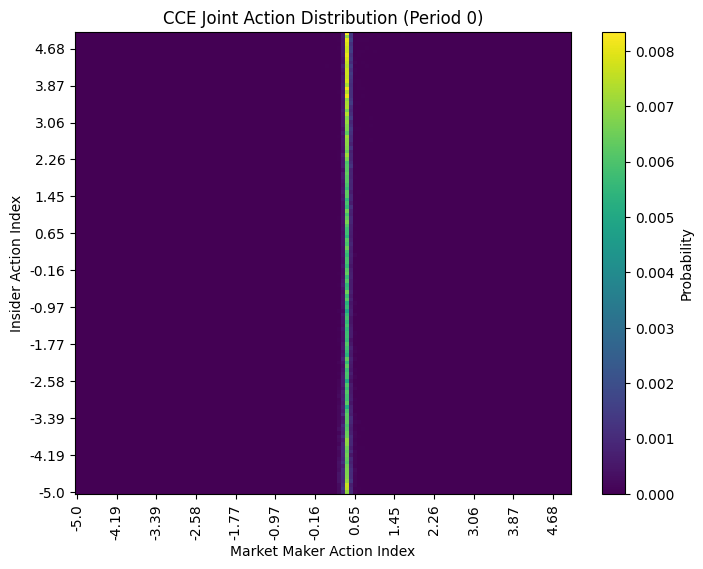

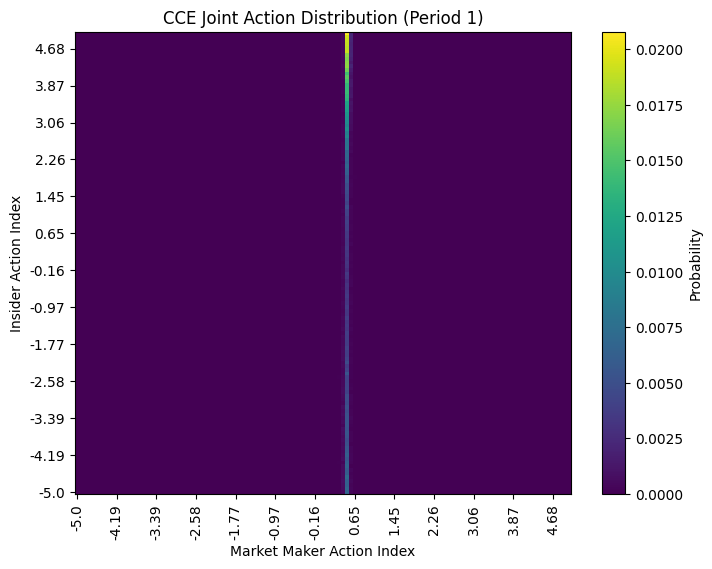

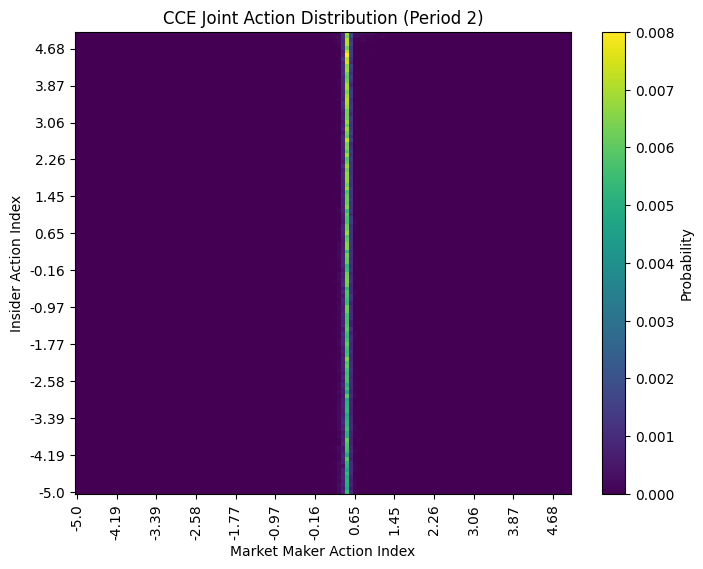

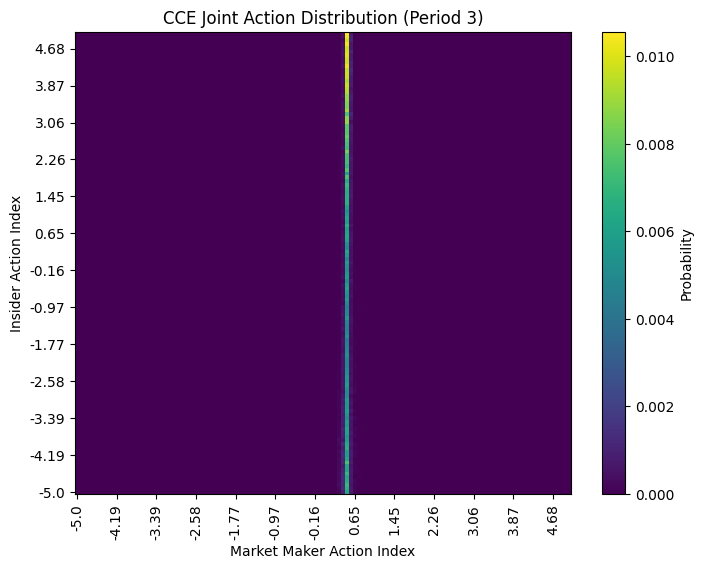

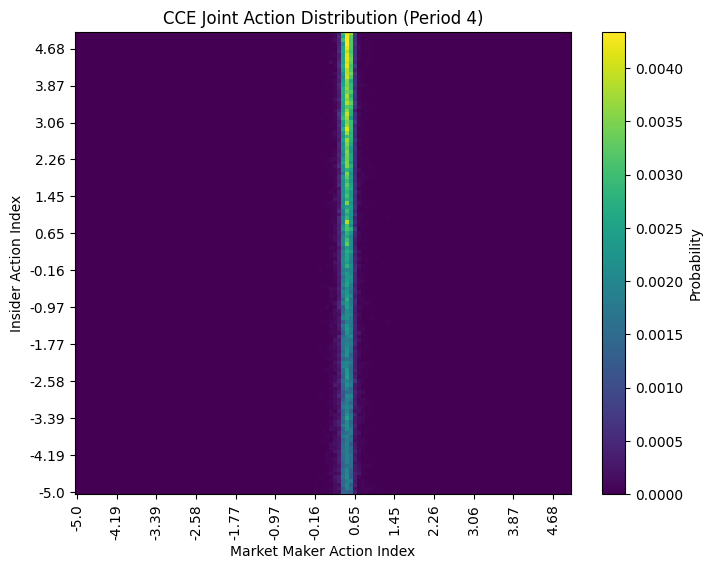

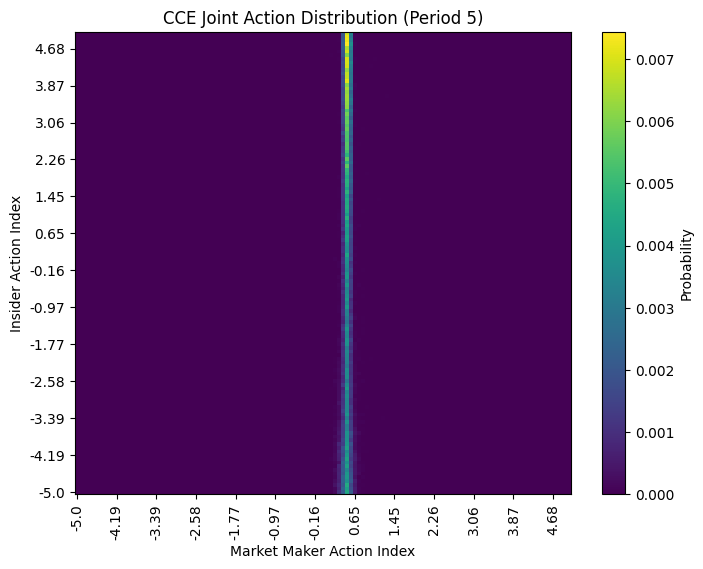

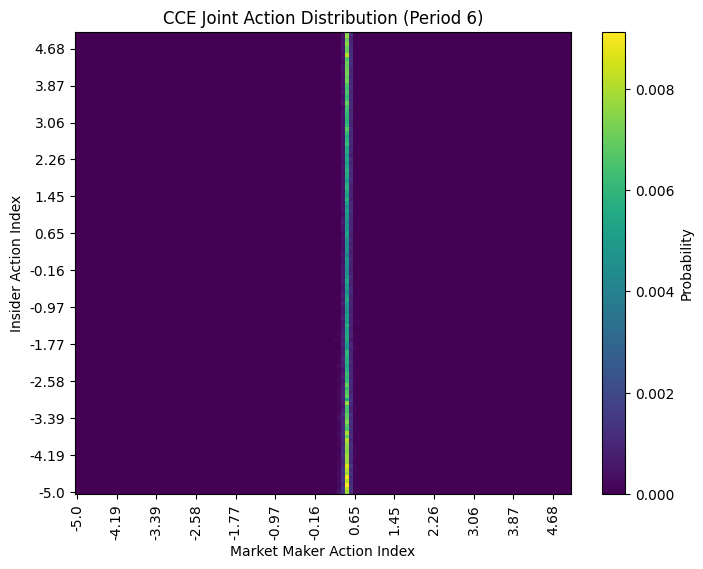

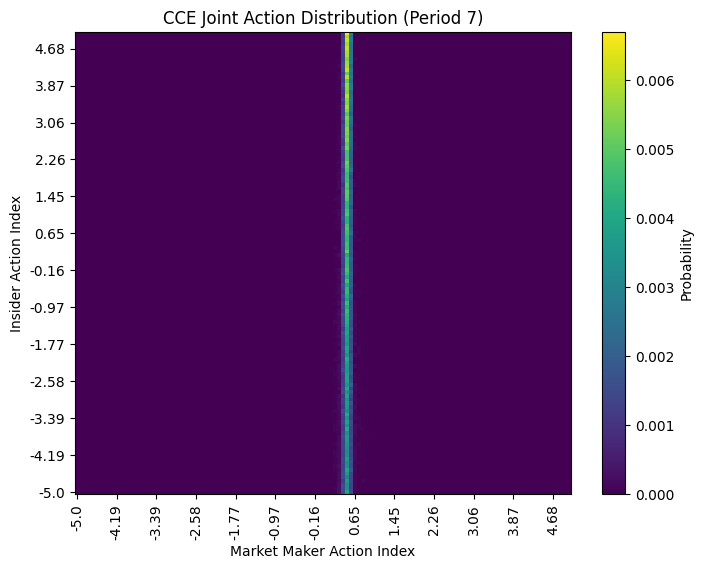

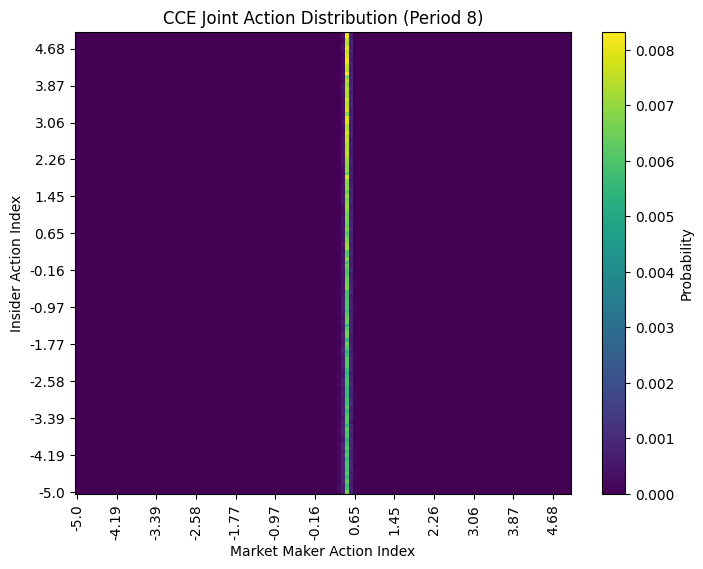

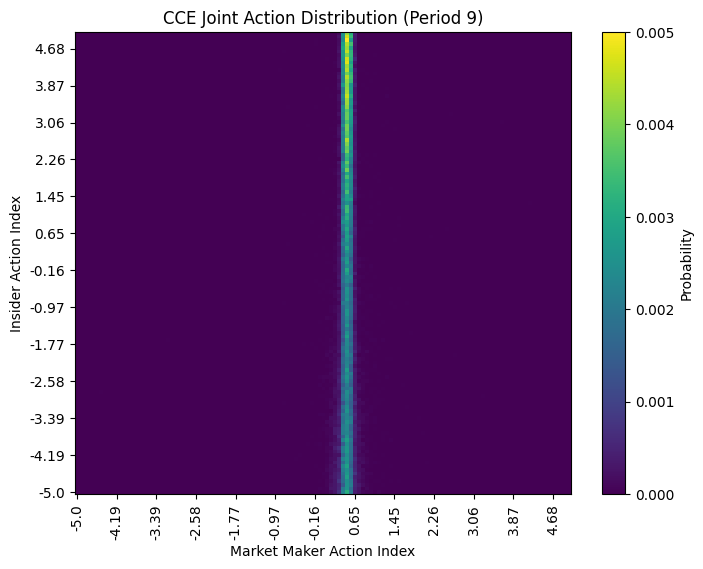

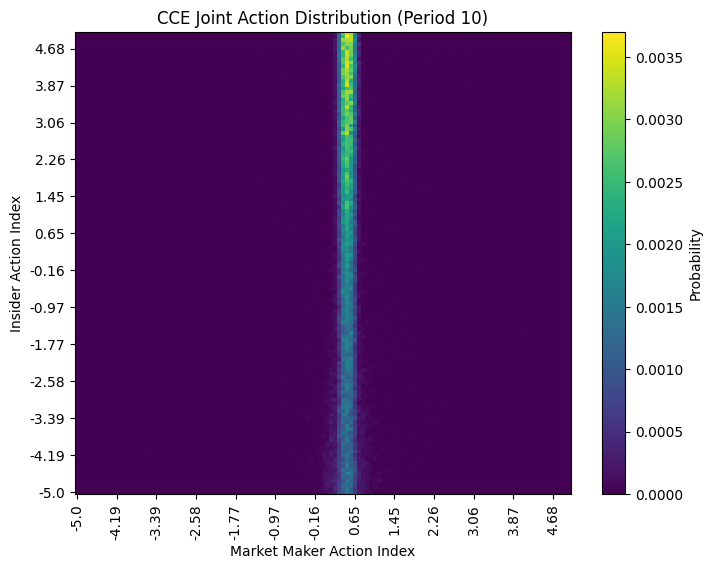

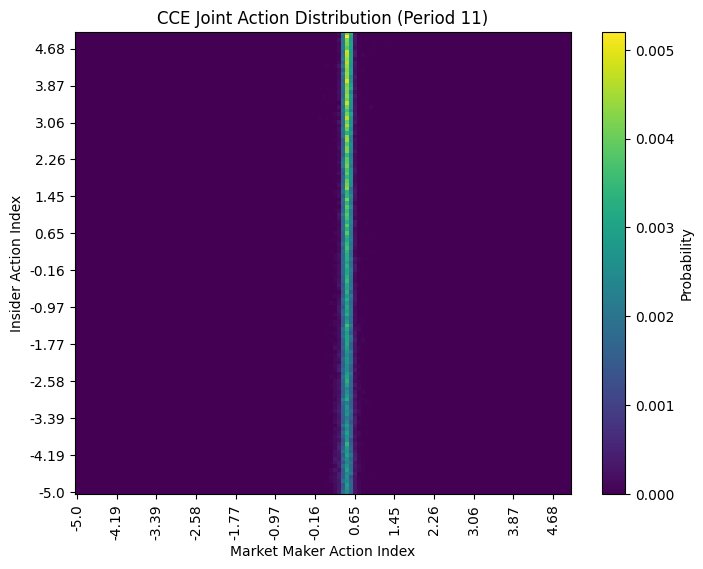

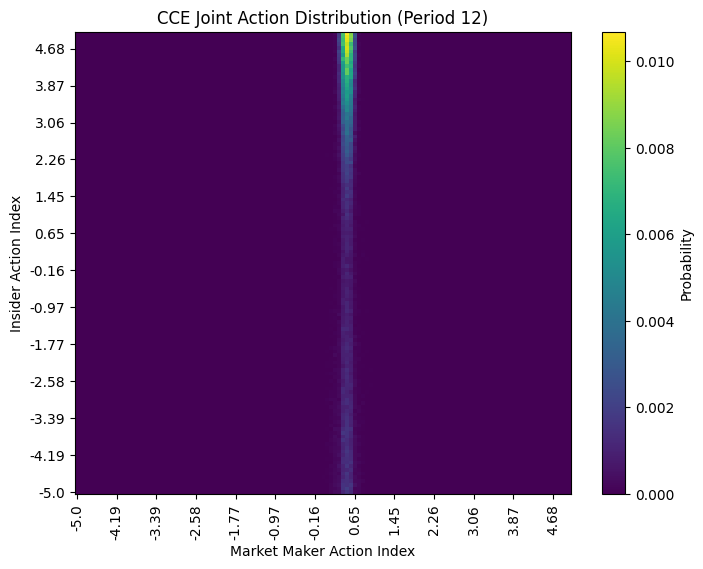

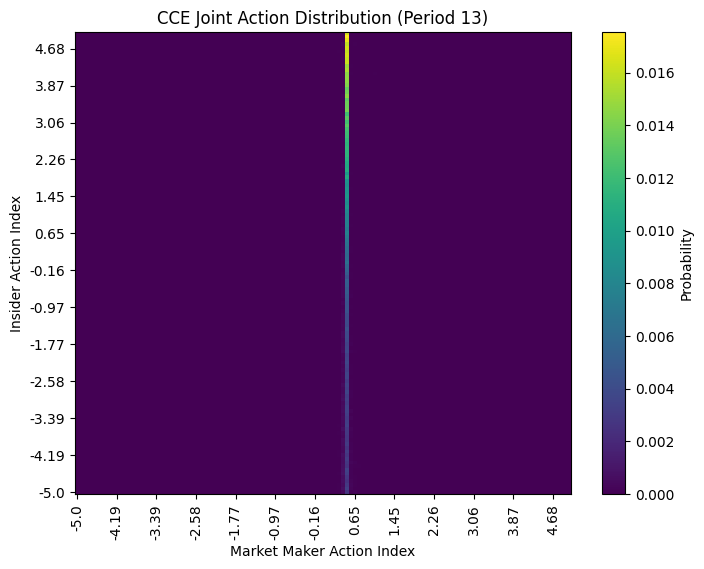

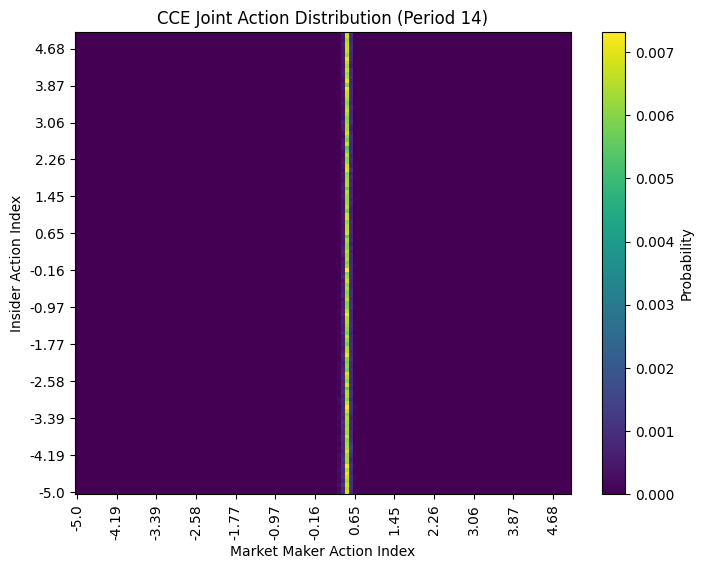

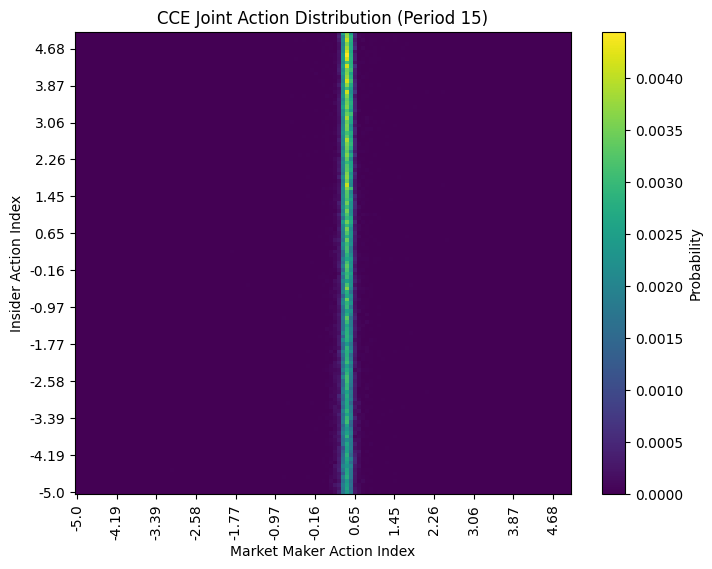

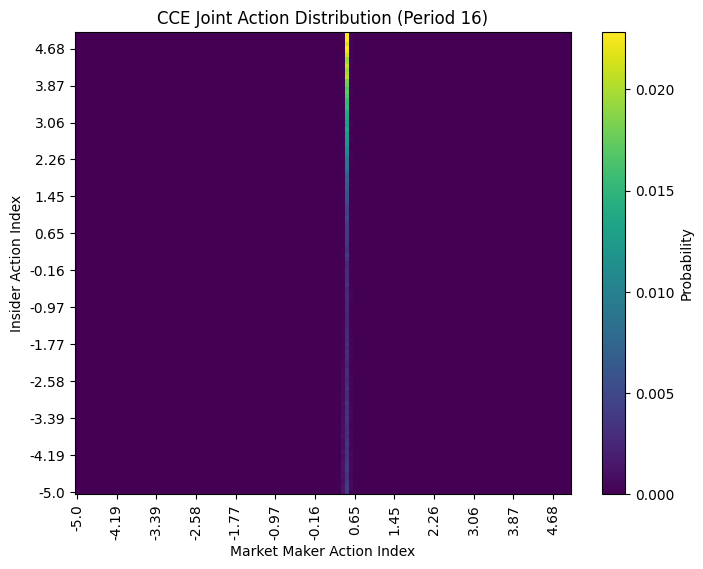

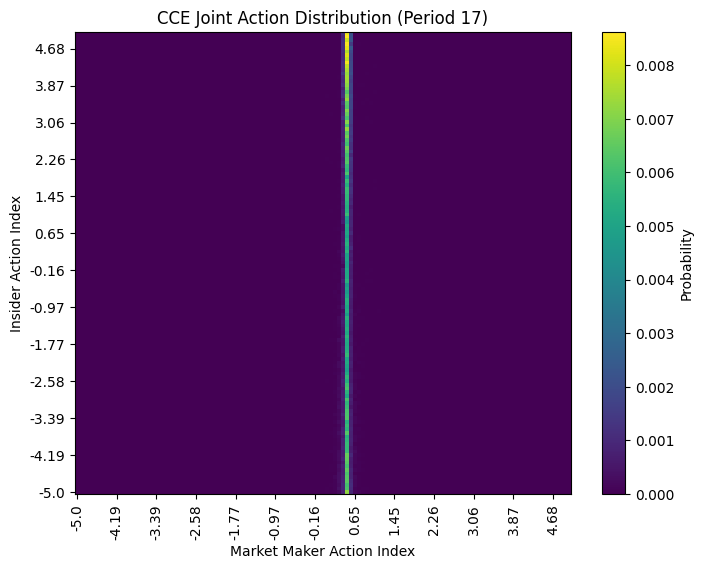

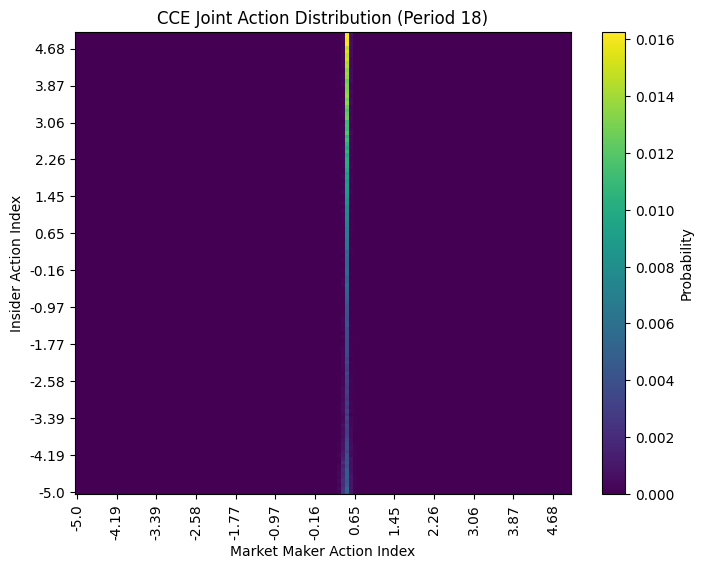

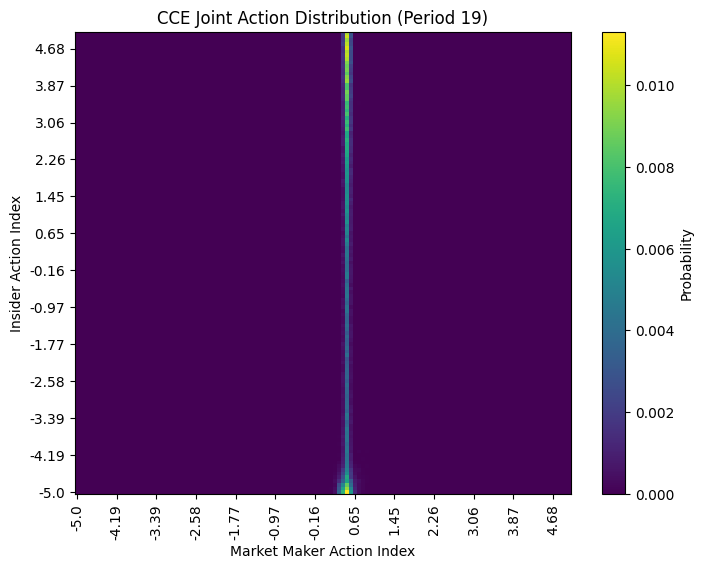

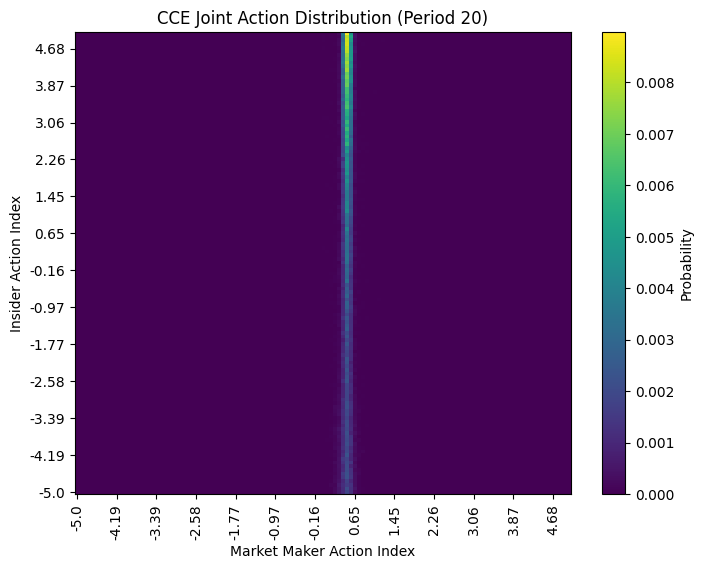

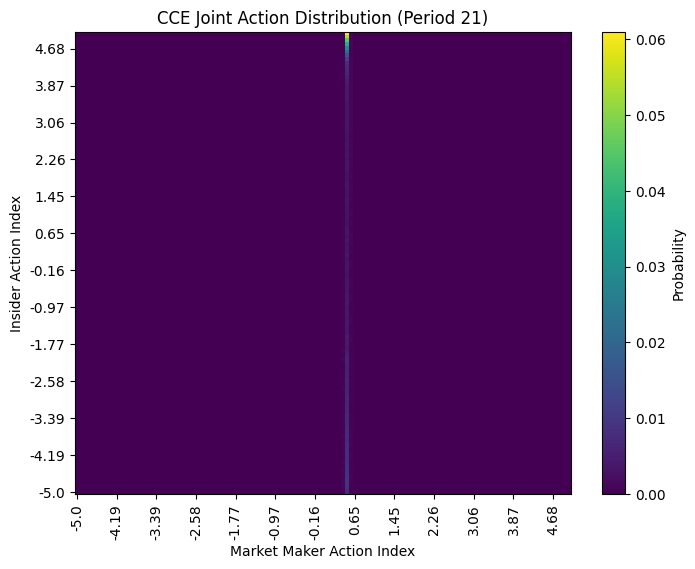

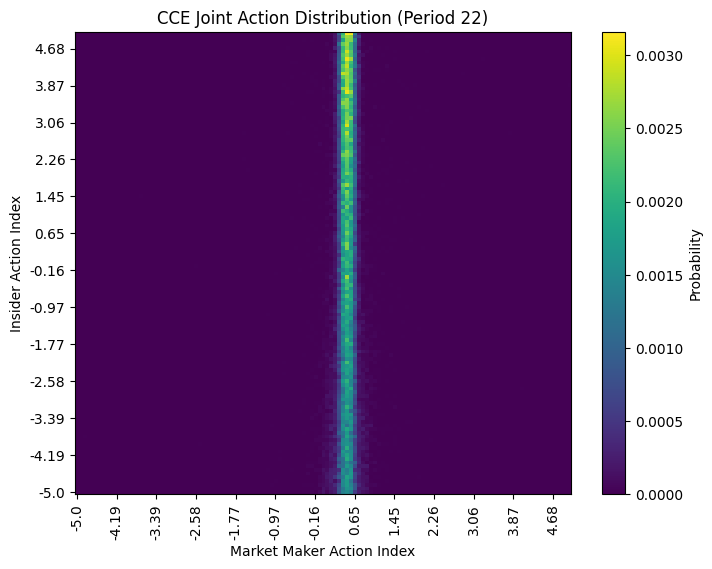

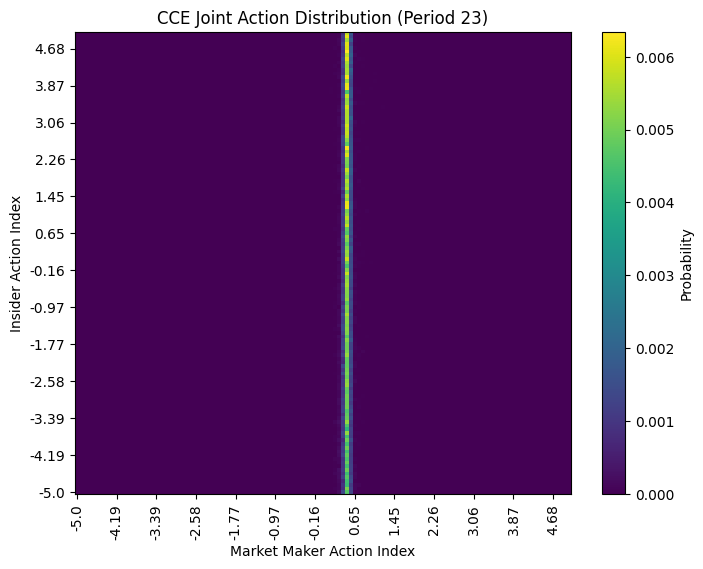

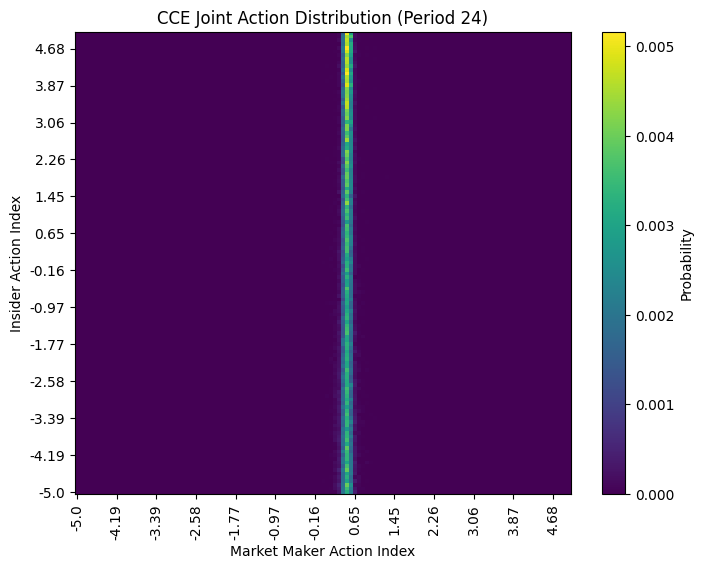

In [42]:
for k in range(25):
    plot_cce_heatmap(cce_dist, INSIDER_ACTIONS, MM_ACTIONS, period=k)

In [31]:
def plot_avg_strategy(avg_strats, actions, agent, period=0):
    """
    Plots the average strategy distribution for a given agent & period.
    """
    plt.figure(figsize=(10, 5))
    plt.plot(actions, avg_strats[agent][period])
    
    plt.title(f"Average Strategy for {agent} (Period {period})")
    plt.xlabel("Action")
    plt.ylabel("Probability")
    plt.grid(True)
    plt.show()


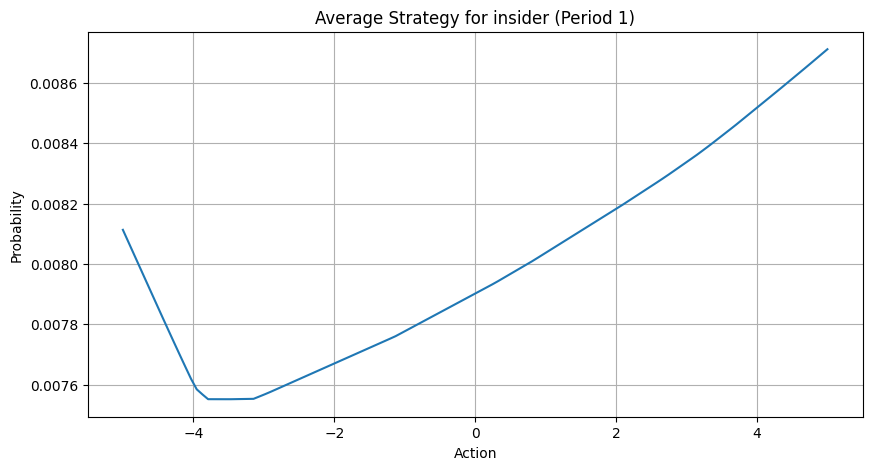

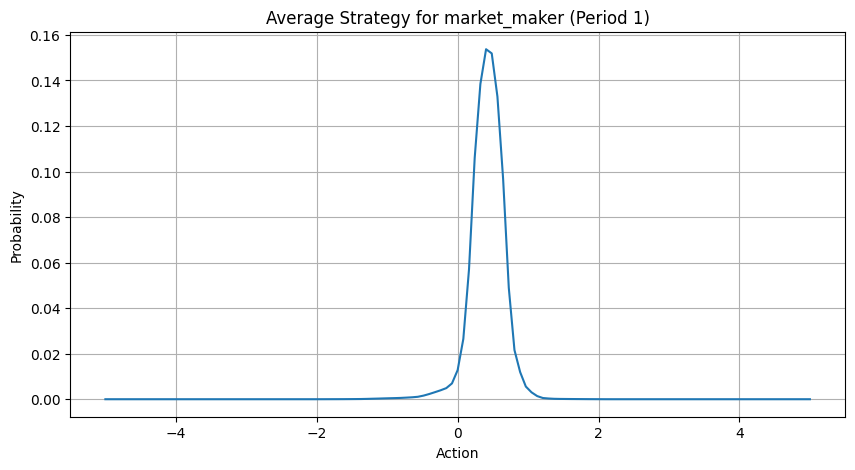

In [35]:
plot_avg_strategy(avg_strats, INSIDER_ACTIONS, "insider", period=1)
plot_avg_strategy(avg_strats, MM_ACTIONS, "market_maker", period=1)


In [11]:
import numpy as np
import math

# ----------------------------
# Exp3 Agent with per-period weights
# ----------------------------
class Exp3AgentPerPeriod:
    def __init__(self, K, T, gamma=0.1, eta=None, rng=None):
        """
        K: number of discrete actions
        T: number of periods (timesteps)
        """
        self.K = K
        self.T = T
        self.gamma = gamma
        self.rng = np.random.RandomState() if rng is None else rng
        self.eta = eta if eta is not None else 0.1

        # weights[period, action]
        self.weights = np.ones((T, K), dtype=np.float64)

    def probs(self, period):
        W = self.weights[period]
        wsum = W.sum()
        if wsum <= 0:
            W = np.ones_like(W)
            wsum = W.sum()
            self.weights[period] = W
        p = (1 - self.gamma) * (W / wsum) + (self.gamma / self.K)
        return p

    def sample_action_index(self, period):
        p = self.probs(period)
        idx = self.rng.choice(self.K, p=p)
        return idx, p[idx]

    def update(self, period, chosen_idx, chosen_prob, reward):
        clip_bound = 10.0
        R_clipped = max(-clip_bound, min(clip_bound, reward))
        R_mapped = (R_clipped + clip_bound) / (2 * clip_bound)
        x_hat = R_mapped / chosen_prob
        self.weights[period, chosen_idx] *= math.exp(self.eta * x_hat / self.K)
        # optional normalization for numerical stability
        max_w = 1e300
        if np.any(self.weights[period] > max_w):
            self.weights[period] = self.weights[period] / np.max(self.weights[period])

# ----------------------------
# Helper: discretize action space
# ----------------------------
def discretize_box(low, high, K):
    """
    Return numpy array of K evenly spaced actions in [low, high].
    """
    return np.linspace(low, high, K)

# ----------------------------
# Training loop using KyleOnePeriodAEC environment
# ----------------------------
def train_mwa_on_kyle(env,
                      num_episodes=500,
                      K=125,
                      gamma=0.1,
                      eta=0.1,
                      seed=0,
                      verbose=True):
    """
    env: instance of KyleOnePeriodAEC
    num_episodes: number of episodes
    K: number of discrete actions per agent
    gamma, eta: Exp3 hyperparameters
    seed: random seed
    """
    rng = np.random.RandomState(seed)
    T = env.T  # number of periods

    # create per-period Exp3 agents
    insider_agent = Exp3AgentPerPeriod(K=K, T=T, gamma=gamma, eta=eta, rng=np.random.RandomState(seed+1))
    mm_agent = Exp3AgentPerPeriod(K=K, T=T, gamma=gamma, eta=eta, rng=np.random.RandomState(seed+2))

    # discretize actions (in [-1,1] -> will be scaled inside env)
    action_grid = discretize_box(-5.0, 5.0, K)

    # bookkeeping
    history = {
        "insider_total_rewards": [],
        "mm_total_rewards": [],
    }

    for ep in range(num_episodes):
        env.reset()
        env.solve_kyle_model()  # optional: compute equilibrium parameters if your env supports it
        insider_cum = 0.0
        mm_cum = 0.0

        last_choice = {"insider": None, "market_maker": None}
        last_prob = {"insider": None, "market_maker": None}

        # loop until episode ends
        while True:
            agent = env.agent_selection
            if agent is None:
                break

            # determine current period for action selection
            period = min(env.timestep, T-1)  # safeguard in case timestep > T

            if agent == "insider":
                idx, p = insider_agent.sample_action_index(period)
                a = np.array([float(action_grid[idx])], dtype=np.float32)
                last_choice["insider"] = idx
                last_prob["insider"] = p
                env.step(a)

            elif agent == "market_maker":
                idx, p = mm_agent.sample_action_index(period)
                a = np.array([float(action_grid[idx])], dtype=np.float32)
                last_choice["market_maker"] = idx
                last_prob["market_maker"] = p
                env.step(a)

                # read rewards after both actions
                rew_dict = getattr(env, "rewards", None)
                if rew_dict is not None:
                    r_ins = float(rew_dict.get("insider", 0.0))
                    r_mm = float(rew_dict.get("market_maker", 0.0))

                    # update agents
                    if last_choice["insider"] is not None:
                        insider_agent.update(period, last_choice["insider"], last_prob["insider"], r_ins)
                    if last_choice["market_maker"] is not None:
                        mm_agent.update(period, last_choice["market_maker"], last_prob["market_maker"], r_mm)

                    insider_cum += r_ins
                    mm_cum += r_mm

            # check termination
            if hasattr(env, "terminations") and all(env.terminations.values()):
                break

        history["insider_total_rewards"].append(insider_cum)
        history["mm_total_rewards"].append(mm_cum)

        if verbose and (ep % max(1, num_episodes // 10) == 0):
            avg_i = np.mean(history["insider_total_rewards"][-max(1, ep//10 + 1):])
            avg_m = np.mean(history["mm_total_rewards"][-max(1, ep//10 + 1):])
            print(f"Episode {ep+1}/{num_episodes}  insider_ep_reward={insider_cum:.3f}  mm_ep_reward={mm_cum:.3f}  recent_avg_insider={avg_i:.3f}")

    # After training: extract best action per period
    best_insider_idx = np.argmax(insider_agent.weights, axis=1)
    best_mm_idx = np.argmax(mm_agent.weights, axis=1)
    best_insider_actions = action_grid[best_insider_idx]
    best_mm_actions = action_grid[best_mm_idx]

    return {
        "insider_agent": insider_agent,
        "mm_agent": mm_agent,
        "history": history,
        "action_grid": action_grid,
        "best_insider_actions": best_insider_actions,
        "best_mm_actions": best_mm_actions,
        "all_weights_insider": insider_agent.weights,
        "all_weights_mm": mm_agent.weights,
    }

# ----------------------------
# Example usage
# ----------------------------
if __name__ == "__main__":
    # Create your KyleOnePeriodAEC environment
    env = KyleOnePeriodAEC(sigma_v=2.0, sigma_u=1.0, p0=0.5, gamma=0.9, action_scaling=1, T=25)

    result = train_mwa_on_kyle(env,
                               num_episodes=30000,
                               K=125,
                               gamma=0.12,
                               eta=0.08,
                               seed=42,
                               verbose=True)

    print("Best insider actions per period:", result["best_insider_actions"])
    print("Best market maker actions per period:", result["best_mm_actions"])


Episode 1/30000  insider_ep_reward=44.621  mm_ep_reward=-189.918  recent_avg_insider=44.621
Episode 3001/30000  insider_ep_reward=25.413  mm_ep_reward=-137.156  recent_avg_insider=1.532
Episode 6001/30000  insider_ep_reward=44.251  mm_ep_reward=-156.402  recent_avg_insider=3.871
Episode 9001/30000  insider_ep_reward=-6.799  mm_ep_reward=-285.239  recent_avg_insider=3.877
Episode 12001/30000  insider_ep_reward=15.784  mm_ep_reward=-147.565  recent_avg_insider=3.636
Episode 15001/30000  insider_ep_reward=-17.744  mm_ep_reward=-172.371  recent_avg_insider=-0.685
Episode 18001/30000  insider_ep_reward=1.959  mm_ep_reward=-326.033  recent_avg_insider=1.888
Episode 21001/30000  insider_ep_reward=-48.048  mm_ep_reward=-65.728  recent_avg_insider=2.138
Episode 24001/30000  insider_ep_reward=-3.478  mm_ep_reward=-58.152  recent_avg_insider=2.027
Episode 27001/30000  insider_ep_reward=-0.393  mm_ep_reward=-67.565  recent_avg_insider=0.785
Best insider actions per period: [3.87096774 0.96774194 4

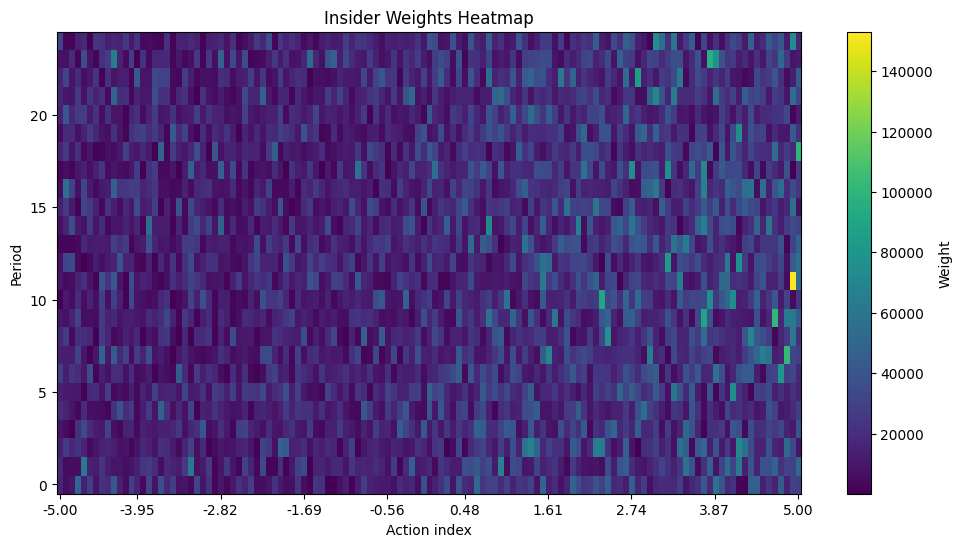

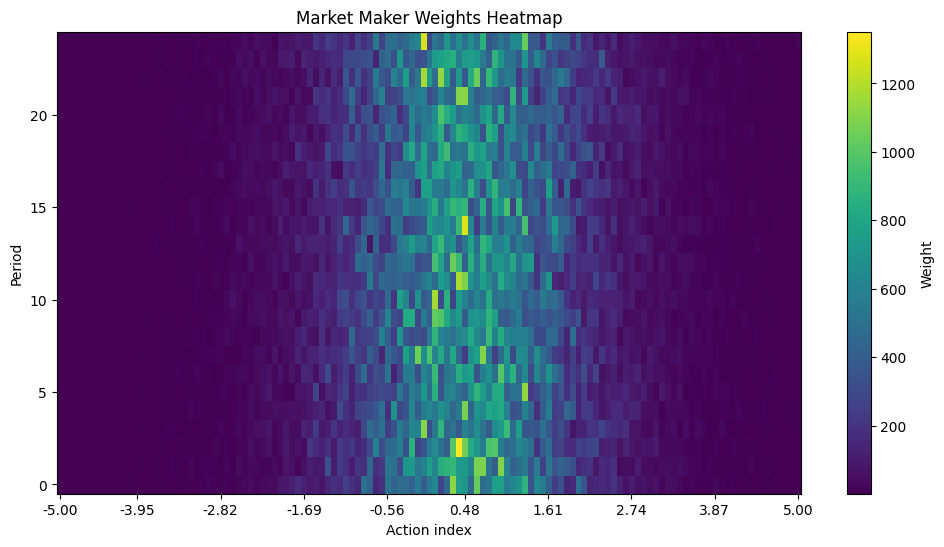

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_weights_heatmap(weights, action_grid, agent_name="Insider"):
    """
    Plot a heatmap of per-period weights.

    Args:
        weights: np.array of shape (T, K)
        action_grid: np.array of length K, the discrete action values
        agent_name: string
    """
    plt.figure(figsize=(12, 6))
    plt.imshow(weights, aspect='auto', cmap='viridis', origin='lower')
    plt.colorbar(label='Weight')
    plt.xlabel("Action index")
    plt.ylabel("Period")
    plt.title(f"{agent_name} Weights Heatmap")
    
    # Optional: show action values on x-axis (sparse)
    K = len(action_grid)
    xticks = np.linspace(0, K-1, min(10, K), dtype=int)
    plt.xticks(xticks, [f"{action_grid[i]:.2f}" for i in xticks])
    
    plt.show()

# ------------------------
# Example usage with your result
# ------------------------
plot_weights_heatmap(result["all_weights_insider"], result["action_grid"], "Insider")
plot_weights_heatmap(result["all_weights_mm"], result["action_grid"], "Market Maker")
